In [1]:
import utils
import os

np = utils.importer('numpy')
plt = utils.importer('matplotlib.pyplot')
pickle = utils.importer('pickle')
meshio = utils.importer('meshio')
dendrogram, linkage, fcluster = utils.importer(
    'scipy.cluster.hierarchy', 'dendrogram', 'linkage', 'fcluster')
KMedoids = utils.importer('sklearn_extra.cluster', 'KMedoids')
KMeans, AgglomerativeClustering = utils.importer(
    'sklearn.cluster', 'KMeans', 'AgglomerativeClustering')
KElbowVisualizer = utils.importer('yellowbrick.cluster', 'KElbowVisualizer')
dendrogram = utils.importer('scipy.cluster.hierarchy', 'dendrogram')
Silhouette, Landscape = utils.importer(
    'gudhi.representations', 'Silhouette', 'Landscape')

In [2]:
malepath = 'E:/TDA/Male/'
male_scans = os.listdir(malepath)
male_nb_scans = len(male_scans)

In [3]:
girlpath = 'E:/TDA/Female/'
girl_scans = os.listdir(girlpath)
girl_nb_scans = len(girl_scans)

all_scans = male_scans + girl_scans
nb_scans = male_nb_scans + girl_nb_scans

In [4]:
def scan_from_index(i):
    if i < male_nb_scans:
        path = malepath + str(all_scans[i])
    else:
        path = girlpath + str(all_scans[i])
    scan = meshio.read(path)
    scan = scan.points
    return scan

In [5]:
def plot_scan_3D_interactive(i):
    scan = scan_from_index(i)
    points_set = utils.point_set(scan)
    points_set.plot(color='green', opacity=0.5, size=2)

In [6]:
with open ('./Data/XY_decolor.bin', 'rb') as fp:
    XY_decolor = pickle.load(fp)

with open ('./Data/XX_decolor.bin', 'rb') as fp:
    XX_decolor = pickle.load(fp)

In [7]:
X_decolor = XY_decolor + XX_decolor
del XX_decolor, XY_decolor

In [8]:
test0 = [xd[0][:-1] for xd in X_decolor]
test1 = [xd[1] for xd in X_decolor]
test2 = [xd[2] for xd in X_decolor]

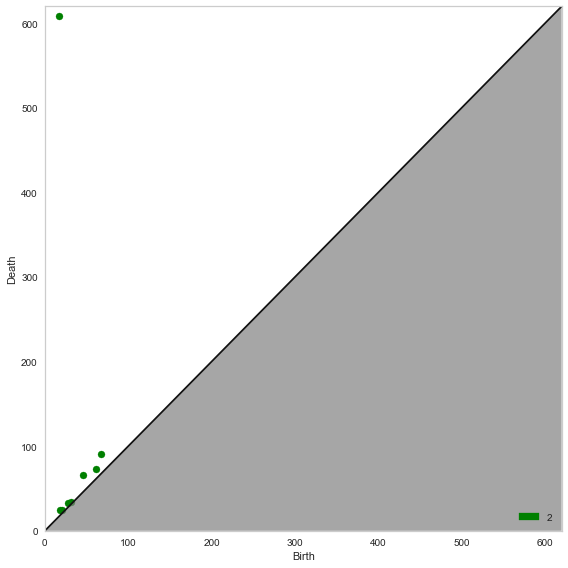

In [9]:
import matplotlib.patches as mpatches

plt.figure(figsize=(8, 8))
temp = np.array(test2[266]).T
X = temp[0]
Y = temp[1]
plt.scatter(X,Y, c='green', label='2')
plt.plot([0, 620], [0, 620], 'k')
plt.fill([0, 620, 620], [0, 620, 0], 'grey', alpha=0.7)
plt.xlim(0, 620)
plt.ylim(0, 620)
plt.xlabel('Birth')
plt.ylabel('Death')
plt.grid(False)
plt.legend(handles=[mpatches.Patch(color='green', label='2')])
plt.tight_layout()
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/M266DiagH1.jpg', dpi=200)
plt.show();

Il semble qu'en privilégiant les homologies $H_1$ et $H_2$ qui naissent le plus tard, on obtienne le meilleur taux de séparabilité des genres. (Je pense que les homologies $H_0$ n'influent pas beaucoup sur les résultats.)

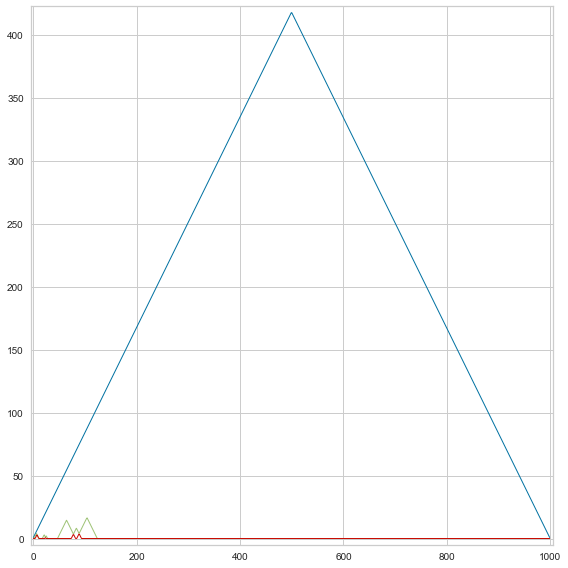

In [10]:
res = 1000
lndscp = Landscape(resolution=res).fit_transform([test2[266]])
fig = plt.figure(figsize=(8, 8))

plt.plot(lndscp[0][:res], linewidth=1)
plt.plot(lndscp[0][res:2*res], linewidth=1)
plt.plot(lndscp[0][2*res:3*res], linewidth=1)
plt.xlim(-5, 1005)
plt.ylim(-5, max(lndscp[0])+5)
plt.tight_layout()
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/M266LandscapeH1.jpg', dpi=200)
plt.show()

In [11]:
n0 = 1440
n1 = n2 = 14400
SH0 = Silhouette(resolution=n0)
sh0 = SH0.fit_transform(test0)

SH1 = Silhouette(resolution=n1, weight=lambda x: x[0])
sh1 = SH1.fit_transform(test1)

SH2 = Silhouette(resolution=n2, weight=lambda x: x[0])
sh2 = SH2.fit_transform(test2)

In [12]:
n = 120
m = (n0+n1+n2)//n
temp = np.array([list(x0)+list(x1)+list(x2)
                for x0, x1, x2 in zip(sh0, sh1, sh2)])
sh = np.array([[np.mean(x[n*i:n*i+n]) for i in range(m)] for x in temp])
sh = (sh - sh.mean()) / sh.std()

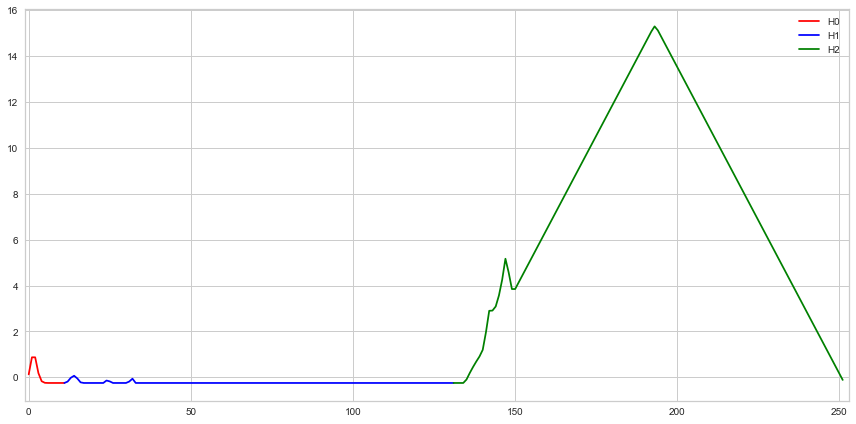

In [13]:
fig = plt.figure(figsize=(12, 6))

plt.xlim(-1, len(sh[266])+1)
plt.plot(sh[266, :n0//n], 'red', label='H0')
plt.plot(range(n0//n-1, (n0+n1)//n),
         sh[266, n0//n-1:(n0+n1)//n], 'blue', label='H1')
plt.plot(range((n0+n1)//n-1, m),
         sh[266, (n0+n1)//n-1:], 'green', label='H2')
plt.legend()
plt.tight_layout()
plt.savefig(
    'E:/Projet-M2/2021-m2-ditex-morphotypes/Images/M266Silhouette.jpg', dpi=200);

## Hierarchical (Ward)

In [14]:
Z = linkage(sh, method='ward')

On peut utiliser `KElbowVisualizer` pour la courbe Elbow...

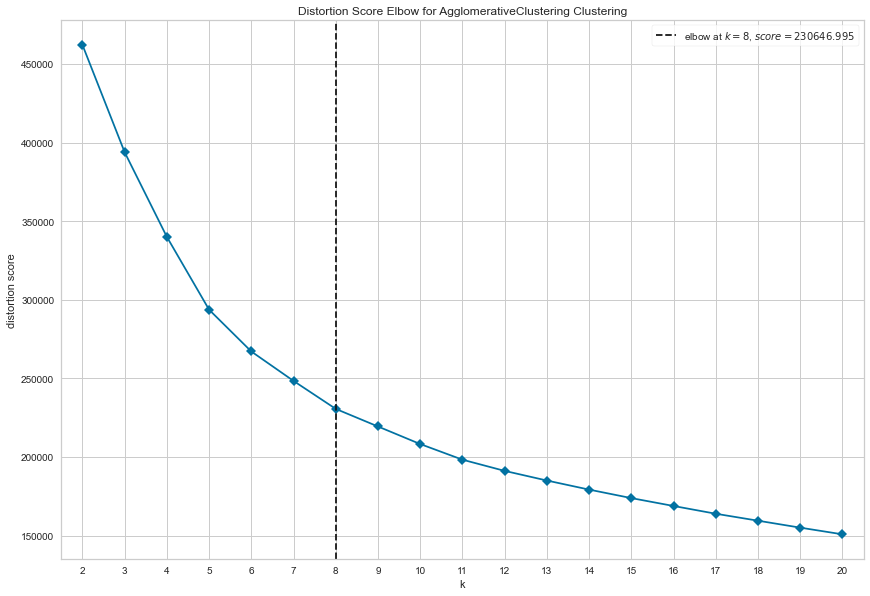

In [15]:
model_ward = AgglomerativeClustering(linkage='ward')
visualizer = KElbowVisualizer(model_ward, k=(2, 21), timings=False)

plt.figure(figsize=(12, 8))
visualizer.fit(sh)
plt.tight_layout()
plt.xticks(range(2, 21, 1))
plt.xlim(1.5, 20.5)
visualizer.show(
    outpath='E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFSWElbow.jpg');

...ou la même méthode que d'habitude.

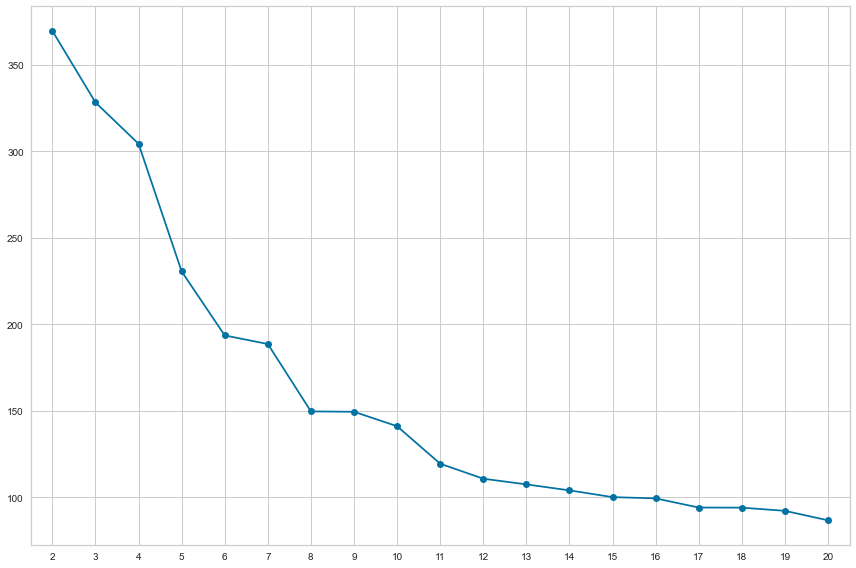

In [16]:
temp = 20

plt.figure(figsize=(12, 8))
plt.plot(range(2, temp+1), Z[::-1, 2][1:temp], 'o-')
plt.xticks(range(2, 21, 1))
plt.xlim(1.5, 20.5)
plt.tight_layout()
plt.grid(True);

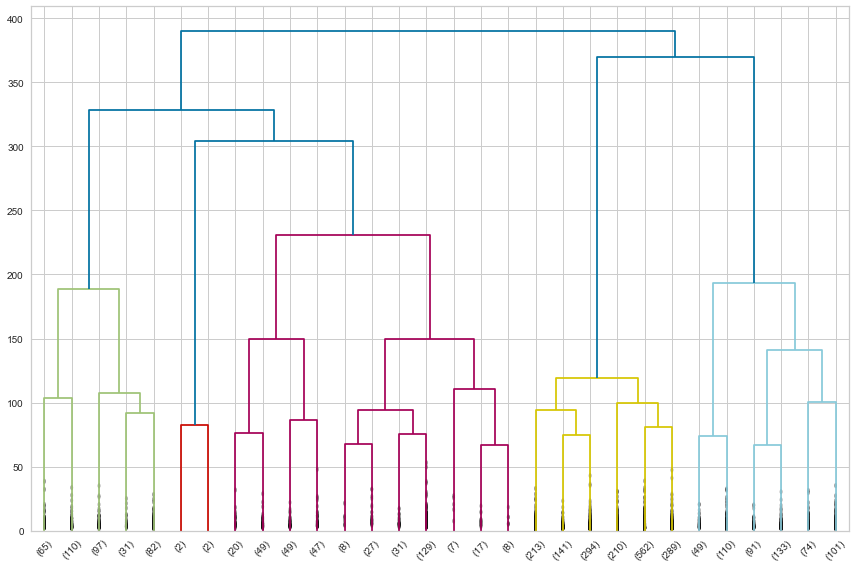

In [17]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)

dendrogram(Z, ax=ax, truncate_mode='lastp', show_contracted=True)
plt.plot([0, 300], [700, 700], 'b--')
plt.tight_layout()
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFSDENDWARDe.jpg');

In [18]:
nb_clus = 7
clusters_ward = fcluster(Z, nb_clus, criterion='maxclust')

In [19]:
dict_clusters_ward = {}
for i in range(1, nb_clus+1):
    dict_clusters_ward[i] = []
for i in range(len(clusters_ward)):
    dict_clusters_ward[clusters_ward[i]].append(i)

for key in dict_clusters_ward:
    male_percentage = np.sum(
        np.array(dict_clusters_ward[key]) < male_nb_scans) / len(dict_clusters_ward[key])
    print('Cluster n°' + str(key), "de taille", len(dict_clusters_ward[key]), 'et ses proportions : Hommes ' + '%.2f' % (
        100*male_percentage), '%, Femmes ' + '%.2f' % (100*(1-male_percentage)), '%\n')

Cluster n°1 de taille 385 et ses proportions : Hommes 5.45 %, Femmes 94.55 %

Cluster n°2 de taille 4 et ses proportions : Hommes 75.00 %, Femmes 25.00 %

Cluster n°3 de taille 165 et ses proportions : Hommes 1.82 %, Femmes 98.18 %

Cluster n°4 de taille 227 et ses proportions : Hommes 26.87 %, Femmes 73.13 %

Cluster n°5 de taille 1709 et ses proportions : Hommes 81.51 %, Femmes 18.49 %

Cluster n°6 de taille 159 et ses proportions : Hommes 3.14 %, Femmes 96.86 %

Cluster n°7 de taille 399 et ses proportions : Hommes 7.77 %, Femmes 92.23 %



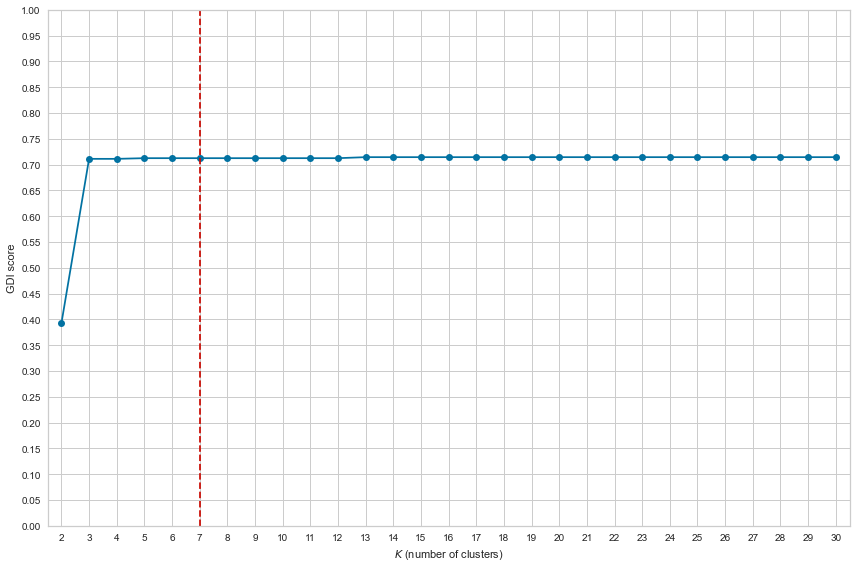

In [20]:
GDI_list = []
borne_nb_clus = 30

for nb_clus in range(2, borne_nb_clus+1):
    clusters = fcluster(Z, nb_clus, criterion='maxclust')
    clusters = clusters.tolist()

    dict_clusters = {}
    for i in range(1, nb_clus+1):
        dict_clusters[i] = []
    for i in range(len(clusters)):
        dict_clusters[clusters[i]].append(i)
    test = 0
    for key in dict_clusters:
        male_percentage = np.sum(
            np.array(dict_clusters[key]) < male_nb_scans) / len(dict_clusters[key])
        test += 2*abs(male_percentage-0.5)*len(dict_clusters[key])
    test /= nb_scans
    GDI_list.append(test)

plt.figure(figsize=(12, 8))
plt.plot(range(2, borne_nb_clus+1), GDI_list, 'o-')
plt.plot([7, 7], [0, 1], 'r--')
plt.ylim(0, 1)
plt.xticks(range(2, 31, 1))
plt.xlim(1.5, 30.5)
plt.yticks(np.arange(0, 1.05, 0.05))
plt.xlabel(r'$K$ (number of clusters)')
plt.ylabel(r'GDI score')
plt.grid(True)
plt.tight_layout()
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFSWGDI.jpg', dpi=200);

In [21]:
GDI = [GDI_list.copy()]

In [22]:
def cluster_medoid(cluster, silhouettes):
    l = len(cluster)
    temp = np.zeros((l, l))

    for i in range(l):
        for j in range(i+1, l):
            temp[i, j] = temp[j, i] = np.linalg.norm(silhouettes[cluster[i]] - silhouettes[cluster[j]])**2

    temp = np.sum(temp, axis=0)
    k = np.argmin(temp)

    return cluster[k]

In [23]:
# for i in range(1, nb_clus+1):
#     medoid = cluster_medoid(dict_clusters_ward[i], sh)
#     print("Le cluster", i, "est de longueur", len(
#         dict_clusters_ward[i]), ", son médoïde est l'individu", medoid, "et voici son scan")
#     plot_scan_3D_interactive(medoid)

## KMeans

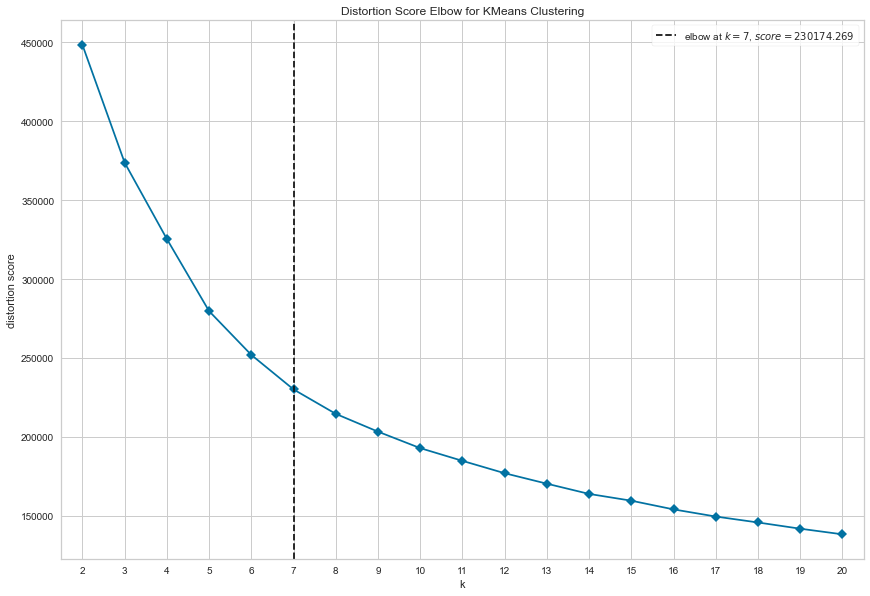

In [24]:
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 21), timings=False)

plt.figure(figsize=(12, 8))
visualizer.fit(sh)
plt.xticks(range(2, 21, 1))
plt.xlim(1.5, 20.5)
plt.tight_layout()
visualizer.show(
    outpath='E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFSMEANElbow.jpg');

In [25]:
nb_clus = 7

kmeans = KMeans(nb_clus, random_state=42, n_init=50, max_iter=1000)
kmeans.fit(sh)
clusters_kmeans = kmeans.fit_predict(sh)

In [26]:
dict_clusters_kmeans = {}
for i in range(1, nb_clus+1):
    dict_clusters_kmeans[i] = []
for i in range(len(clusters_kmeans)):
    dict_clusters_kmeans[clusters_kmeans[i]+1].append(i)

for key in dict_clusters_kmeans:
    male_percentage = np.sum(
        np.array(dict_clusters_kmeans[key]) < male_nb_scans) / len(dict_clusters_kmeans[key])
    print('Cluster n°' + str(key), "de taille", len(dict_clusters_kmeans[key]), 'et ses proportions : Hommes ' + '%.2f' % (
        100*male_percentage), '%, Femmes ' + '%.2f' % (100*(1-male_percentage)), '%\n')

Cluster n°1 de taille 4 et ses proportions : Hommes 75.00 %, Femmes 25.00 %

Cluster n°2 de taille 1818 et ses proportions : Hommes 79.10 %, Femmes 20.90 %

Cluster n°3 de taille 314 et ses proportions : Hommes 2.23 %, Femmes 97.77 %

Cluster n°4 de taille 236 et ses proportions : Hommes 5.93 %, Femmes 94.07 %

Cluster n°5 de taille 172 et ses proportions : Hommes 17.44 %, Femmes 82.56 %

Cluster n°6 de taille 131 et ses proportions : Hommes 2.29 %, Femmes 97.71 %

Cluster n°7 de taille 373 et ses proportions : Hommes 5.90 %, Femmes 94.10 %



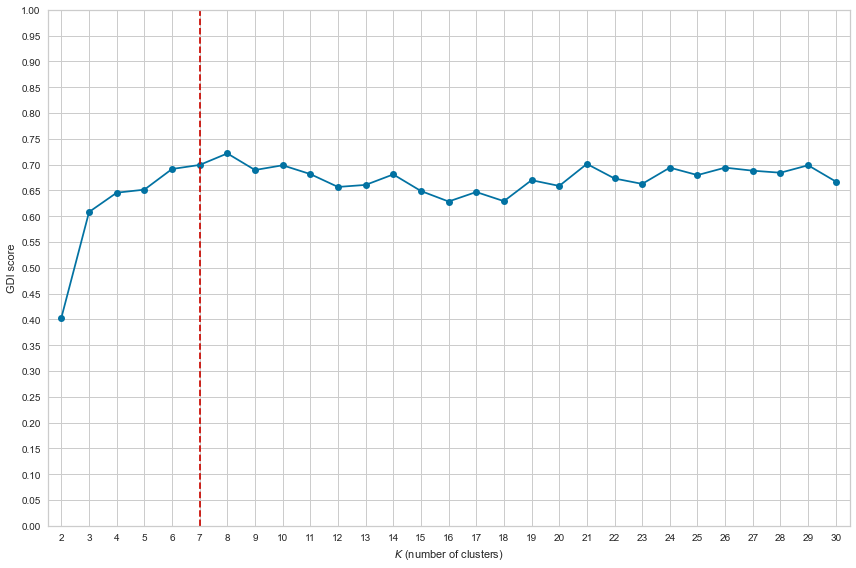

In [27]:
GDI_list = []
borne_nb_clus = 30

for nb_clus in range(2, borne_nb_clus+1):
    clusters = KMeans(nb_clus, random_state=42).fit_predict(sh)
    clusters = clusters.tolist()

    dict_clusters = {}
    for i in range(1, nb_clus+1):
        dict_clusters[i] = []
    for i in range(len(clusters)):
        dict_clusters[clusters[i]+1].append(i)
    test = 0
    for key in dict_clusters:
        male_percentage = np.sum(
            np.array(dict_clusters[key]) < male_nb_scans) / len(dict_clusters[key])
        test += 2*abs(male_percentage-0.5)*len(dict_clusters[key])
    test /= nb_scans
    GDI_list.append(test)

plt.figure(figsize=(12, 8))
plt.plot(range(2, borne_nb_clus+1), GDI_list, 'o-')
plt.plot([7, 7], [0, 1], 'r--')
plt.ylim(0, 1)
plt.xticks(range(2, 31, 1))
plt.xlim(1.5, 30.5)
plt.yticks(np.arange(0, 1.05, 0.05))
plt.xlabel(r'$K$ (number of clusters)')
plt.ylabel(r'GDI score')
plt.grid(True)
plt.tight_layout()
plt.savefig(
    'E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFSMEANGDI.jpg', dpi=200);

In [28]:
GDI.append(GDI_list.copy())

In [29]:
# for i in range(1, nb_clus+1):
#     medoid = cluster_medoid(dict_clusters_kmeans[i], sh)
#     print("Le cluster", i, "est de longueur", len(
#         dict_clusters_kmeans[i]), ", son médoïde est l'individu", medoid, "et voici son scan")
#     plot_scan_3D_interactive(medoid)

## KMedoids

La visualisation Elbow pour PAM est un peu lente.

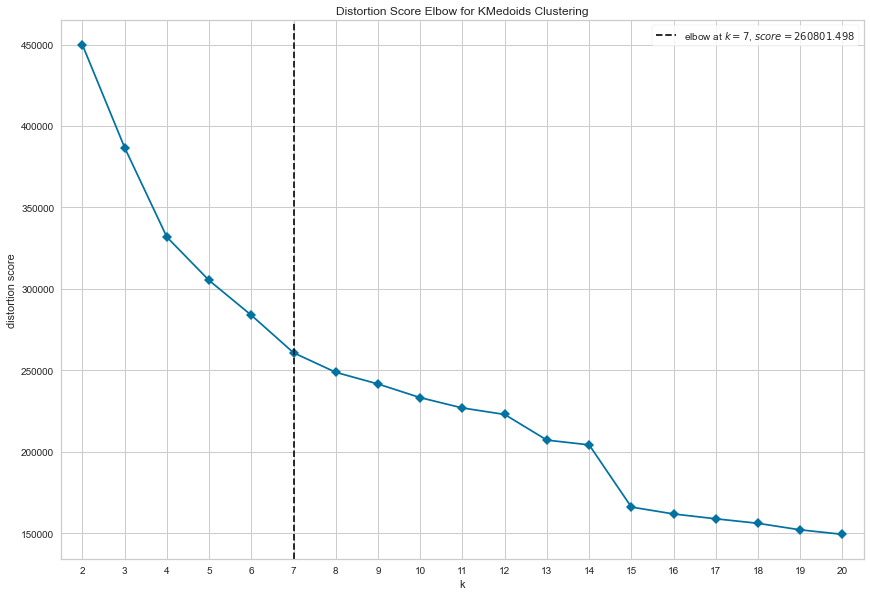

In [30]:
model = KMedoids(method='pam', init='k-medoids++', random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 21), timings=False)

plt.figure(figsize=(12, 8))
visualizer.fit(sh)
plt.xticks(range(2, 21, 1))
plt.xlim(1.5, 20.5)
plt.tight_layout()
visualizer.show(
    outpath='E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFSPAMElbow.jpg');

In [31]:
nb_clus = 7

kmed = KMedoids(nb_clus, method='pam', init='k-medoids++', random_state=42)
kmed.fit(sh)
clusters_kmed = kmed.labels_

In [32]:
dict_clusters_kmed = {}
for i in range(1, nb_clus+1):
    dict_clusters_kmed[i] = []
for i in range(len(clusters_kmed)):
    dict_clusters_kmed[clusters_kmed[i]+1].append(i)

for key in dict_clusters_kmed:
    male_percentage = np.sum(
        np.array(dict_clusters_kmed[key]) < male_nb_scans) / len(dict_clusters_kmed[key])
    print('Cluster n°' + str(key), "de taille", len(dict_clusters_kmed[key]), 'et ses proportions : Hommes ' + '%.2f' % (
        100*male_percentage), '%, Femmes ' + '%.2f' % (100*(1-male_percentage)), '%\n')

Cluster n°1 de taille 1739 et ses proportions : Hommes 81.20 %, Femmes 18.80 %

Cluster n°2 de taille 224 et ses proportions : Hommes 5.36 %, Femmes 94.64 %

Cluster n°3 de taille 263 et ses proportions : Hommes 1.52 %, Femmes 98.48 %

Cluster n°4 de taille 269 et ses proportions : Hommes 7.06 %, Femmes 92.94 %

Cluster n°5 de taille 206 et ses proportions : Hommes 23.30 %, Femmes 76.70 %

Cluster n°6 de taille 212 et ses proportions : Hommes 8.96 %, Femmes 91.04 %

Cluster n°7 de taille 135 et ses proportions : Hommes 2.22 %, Femmes 97.78 %



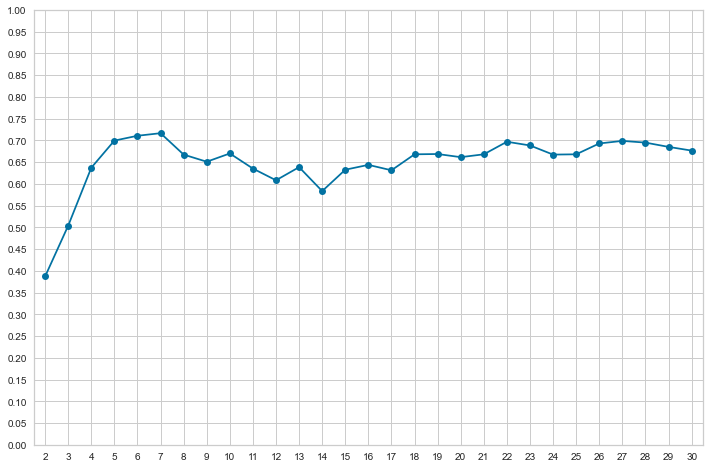

In [33]:
GDI_list = []
borne_nb_clus = 30

for nb_clus in range(2, borne_nb_clus+1):
    kmed = KMedoids(n_clusters=nb_clus, method='pam',
                    init='k-medoids++', random_state=42).fit(sh)
    clusters = kmed.labels_

    dict_clusters = {}
    for j in range(nb_clus):
        dict_clusters[j] = []
    for j in range(len(clusters)):
        dict_clusters[clusters[j]].append(j)
    test = 0
    for key in dict_clusters:
        male_percentage = np.sum(
            np.array(dict_clusters[key]) < male_nb_scans) / len(dict_clusters[key])
        test += 2*abs(male_percentage-0.5)*len(dict_clusters[key])
    test /= nb_scans
    GDI_list.append(test)

fig = plt.figure(figsize=(12, 8))
plt.xlim(1.5, 30.5)
plt.xticks(np.arange(2, 31, 1))
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.05, 0.05))
plt.plot(range(2, borne_nb_clus+1), GDI_list, 'o-')
plt.grid(True)
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFSPAMGDI.jpg', dpi=200);

In [34]:
GDI.append(GDI_list.copy())

with open('./Data/Silhouette.bin', 'wb') as fp:
    pickle.dump(GDI, fp)

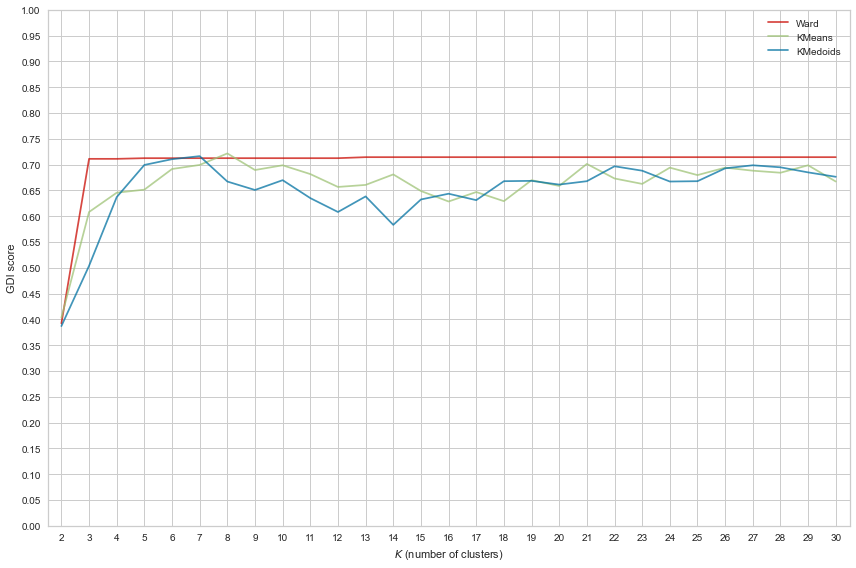

In [35]:
plt.figure(figsize=(12, 8))
plt.plot(range(2, borne_nb_clus+1), GDI[0], 'r', alpha=0.75, label='Ward')
plt.plot(range(2, borne_nb_clus+1), GDI[1], 'g', alpha=0.75, label='KMeans')
plt.plot(range(2, borne_nb_clus+1), GDI[2], 'b', alpha=0.75, label='KMedoids')
plt.ylim(0, 1)
plt.xticks(range(2, 31, 1))
plt.xlim(1.5, 30.5)
plt.yticks(np.arange(0, 1.05, 0.05))
plt.xlabel(r'$K$ (number of clusters)')
plt.ylabel(r'GDI score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFSGDI.jpg', dpi=200);

In [36]:
# indices = kmed.medoid_indices_

# for i in range(indices.shape[0]):
#     medoid = indices[i]
#     print("Le cluster", i+1, "est de longueur", len(
#         dict_clusters_kmed[i+1]), ", son médoïde est l'individu", medoid, "et voici son scan")
#     plot_scan_3D_interactive(medoid)